In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline 

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR , SVC
from sklearn.ensemble import RandomForestRegressor , RandomForestClassifier
from sklearn.ensemble import AdaBoostRegressor ,AdaBoostClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering   #hiearichal clustering 

from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score 
from sklearn.metrics import accuracy_score , f1_score , recall_score , classification_report , confusion_matrix , silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
#uploading the cleaner data 
df=pd.read_csv('cleaned_earthquake.csv')


In [21]:
df.columns

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'depthError', 'magNst', 'status', 'locationSource', 'magSource', 'day',
       'gap_conservative', 'dmin_conservative', 'gap_median', 'dmin_median'],
      dtype='object')

In [3]:
#just checking 
df.isnull().sum()

time                 0
latitude             0
longitude            0
depth                0
mag                  0
magType              0
nst                  0
gap                  0
dmin                 0
rms                  0
net                  0
id                   0
updated              0
place                0
type                 0
depthError           0
magNst               0
status               0
locationSource       0
magSource            0
day                  0
gap_conservative     0
dmin_conservative    0
gap_median           0
dmin_median          0
dtype: int64

In [4]:
df.head(2)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,depthError,magNst,status,locationSource,magSource,day,gap_conservative,dmin_conservative,gap_median,dmin_median
0,2024-01-26 04:52:42.967000+00:00,31.604,-104.2130,4.4198,1.7,ml,18.0,69.00,0.10000,0.50,...,1.292059,13.0,automatic,tx,tx,2024-01-26,69.0,0.1,69.00,0.10000
1,2024-01-26 04:42:50.711000+00:00,64.501,-146.9058,4.2000,1.4,ml,1.0,89.91,0.05953,0.75,...,0.200000,1.0,automatic,ak,ak,2024-01-26,360.0,5.0,89.91,0.05953


In [5]:
#feature selection 
numeric_features=['longitude','latitude','depth','gap','nst','dmin','rms','mag']

X=df[numeric_features]
y=df['mag']

In [6]:
print(X)

       longitude   latitude    depth     gap   nst      dmin   rms   mag
0    -104.213000  31.604000   4.4198   69.00  18.0  0.100000  0.50  1.70
1    -146.905800  64.501000   4.2000   89.91   1.0  0.059530  0.75  1.40
2    -147.554300  63.529000  13.1000   89.91   1.0  0.059530  0.62  1.60
3    -122.797165  38.833168   1.7300   65.00   9.0  0.007468  0.02  0.40
4    -150.971900  63.546200   0.0000   89.91   1.0  0.059530  0.80  1.20
...          ...        ...      ...     ...   ...       ...   ...   ...
8781  -66.835500  18.097333  18.3100  106.00   6.0  0.128500  0.08  2.14
8782 -164.123600  54.771700   9.6690   91.00  47.0  0.002000  0.70  3.60
8783 -164.104667  54.748000   4.2000  211.00   4.0  0.059530  0.13  0.67
8784   16.286000  43.462200  10.0000   78.00  17.0  1.440000  0.56  2.70
8785 -164.065400  54.761900   7.4430   83.00  23.0  0.037000  0.98  3.00

[8786 rows x 8 columns]


In [7]:
y

0       1.70
1       1.40
2       1.60
3       0.40
4       1.20
        ... 
8781    2.14
8782    3.60
8783    0.67
8784    2.70
8785    3.00
Name: mag, Length: 8786, dtype: float64

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [9]:
df.shape

(8786, 25)

In [10]:
X_train.shape ,X_test.shape

((6589, 8), (2197, 8))

In [11]:
#standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# choose same value as min_samples
k = 10  

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

# take distance to kth nearest neighbor
k_distances = distances[:, k-1]

In [13]:
k_distances = np.sort(k_distances)

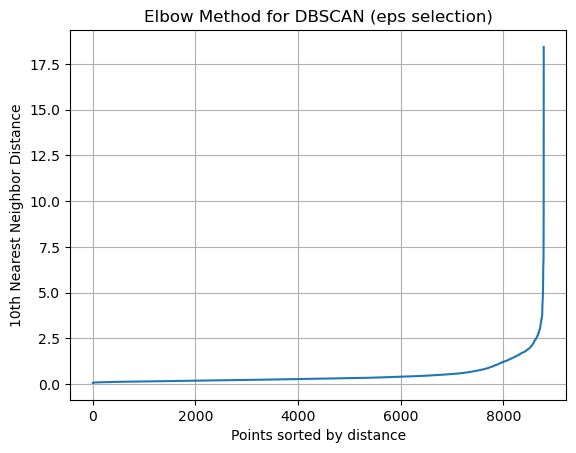

In [14]:
import matplotlib.pyplot as plt

plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}th Nearest Neighbor Distance")
plt.title("Elbow Method for DBSCAN (eps selection)")
plt.grid()
plt.show()

there is a sharp jump around ~1.5 to 2.0  <br>
so we will take the eps value 1.7

In [15]:
dbscan = DBSCAN(eps=1.7, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)

In [16]:
# remove noise (-1)
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    db_score = silhouette_score(X_scaled[mask], db_labels[mask])
else:
    db_score = -1  # failed clustering

# noise percentage
noise_ratio = np.sum(db_labels == -1) / len(db_labels)

print("DBSCAN Silhouette:", db_score)
print("DBSCAN Noise %:", noise_ratio)
print("DBSCAN Clusters:", set(db_labels))

DBSCAN Silhouette: 0.49321298519951035
DBSCAN Noise %: 0.026405645344866835
DBSCAN Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}


In [17]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

  File "c:\Users\HP\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\HP\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\anaconda3\Lib\subprocess.py", line 15

In [18]:
km_score = silhouette_score(X_scaled, km_labels)

print("K-Means Silhouette:", km_score)
print("K-Means Clusters:", set(km_labels))

K-Means Silhouette: 0.375372585345462
K-Means Clusters: {np.int32(0), np.int32(1), np.int32(2), np.int32(3)}


In [19]:
print("\n===== FINAL COMPARISON =====")

print(f"DBSCAN → Silhouette: {db_score}, Noise: {noise_ratio}")
print(f"K-Means → Silhouette: {km_score}")

if db_score > km_score:
    print("DBSCAN better (structure-based clustering)")
else:
    print("K-Means better (compact clusters)")


===== FINAL COMPARISON =====
DBSCAN → Silhouette: 0.49321298519951035, Noise: 0.026405645344866835
K-Means → Silhouette: 0.375372585345462
DBSCAN better (structure-based clustering)


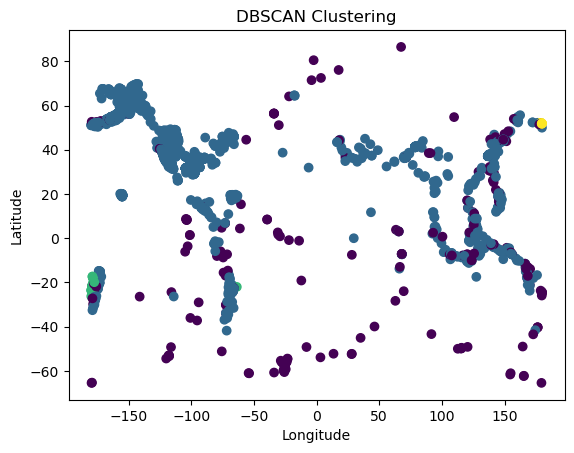

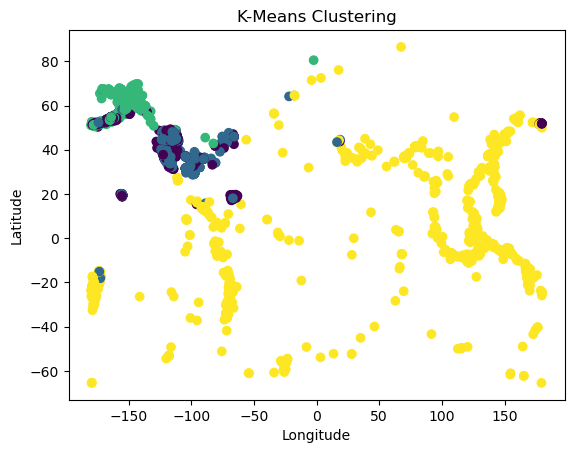

In [20]:
import matplotlib.pyplot as plt

# DBSCAN
plt.scatter(X['longitude'], X['latitude'], c=db_labels)
plt.title("DBSCAN Clustering")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# K-Means
plt.scatter(X['longitude'], X['latitude'], c=km_labels)
plt.title("K-Means Clustering")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()